In [3]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

DATA_DIR = "data"
DB_PATH = "db/inventra.db"

sales = pd.read_csv(f"{DATA_DIR}/sales.csv")
inventory = pd.read_csv(f"{DATA_DIR}/inventory.csv")
finance = pd.read_csv(f"{DATA_DIR}/finance.csv")
vendors = pd.read_csv(f"{DATA_DIR}/vendors.csv")

print("sales:    ", sales.shape)
print("inventory:", inventory.shape)
print("finance:  ", finance.shape)
print("vendors:  ", vendors.shape)

sales:     (9157, 9)
inventory: (100, 8)
finance:   (5000, 6)
vendors:   (20, 13)


In [5]:
conn = sqlite3.connect(DB_PATH)
sales = pd.read_sql("SELECT * FROM sales", conn)
inventory = pd.read_sql("SELECT sku, name, category, region AS home_region FROM inventory", conn)


In [9]:
df = sales.merge(inventory, on="sku", how="left")
df.head(2)

,id,date,sku,qty,revenue,region,temperature,rainfall,humidity,weather_condition,name,category,home_region
0,1,2022-10-03,SKU060,1,3953.37,North,16.7,40.9,67.0,Rainy,Epilator,Personal Care,South
1,2,2020-06-22,SKU058,9,18397.09,South,24.4,57.4,82.0,Rainy,Hair Trimmer,Personal Care,Central


In [11]:
# inventory.head(2)
before = len(df)
df["temperature"] = pd.to_numeric(df["temperature"], errors="coerce")
n_bad = df["temperature"].isna().sum()
print(f"{n_bad} row(s) with non-numeric temperature -> dropping")
df = df.dropna(subset=["temperature"]).reset_index(drop=True)

1 row(s) with non-numeric temperature -> dropping


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9156 entries, 0 to 9155
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 9156 non-null   int64  
 1   date               9156 non-null   object 
 2   sku                9156 non-null   object 
 3   qty                9156 non-null   int64  
 4   revenue            9156 non-null   float64
 5   region             9156 non-null   object 
 6   temperature        9156 non-null   float64
 7   rainfall           9156 non-null   float64
 8   humidity           9156 non-null   float64
 9   weather_condition  9156 non-null   object 
 10  name               9156 non-null   object 
 11  category           9156 non-null   object 
 12  home_region        9156 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 930.0+ KB


In [13]:
df["date"] = pd.to_datetime(df["date"])

# feature engineering 
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)


In [14]:
df.head(2)

,id,date,sku,qty,revenue,region,temperature,rainfall,humidity,weather_condition,name,category,home_region,month,day_of_week,is_weekend
0,1,2022-10-03,SKU060,1,3953.37,North,16.7,40.9,67.0,Rainy,Epilator,Personal Care,South,10,0,0
1,2,2020-06-22,SKU058,9,18397.09,South,24.4,57.4,82.0,Rainy,Hair Trimmer,Personal Care,Central,6,0,0


In [22]:
from sklearn.preprocessing import LabelEncoder
encoders = {}
for col in ["sku", "category", "region", "weather_condition"]:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    encoders[col] = le

In [24]:
feature_cols = [
    "sku_enc", "category_enc", "region_enc", "weather_condition_enc",
    "temperature", "rainfall", "humidity",
    "month", "day_of_week", "is_weekend",
]

target_col = "qty"

X = df[feature_cols]
y = df[target_col]



In [35]:
df_sorted = df.sort_values("date").reset_index(drop=True)
# df_sorted.date.describe()
# df_sorted.head(40)

split_idx = int(len(df_sorted) * 0.85)
split_date = df_sorted.loc[split_idx, "date"]

train_df = df_sorted[df_sorted["date"] < split_date]
test_df = df_sorted[df_sorted["date"] >= split_date]

In [62]:
train_df.shape,test_df.shape

((7778, 20), (1378, 20))

In [ ]:
X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

In [42]:
# pip install xgboost


In [ ]:
# df_sorted.date.describe()


In [43]:
import xgboost as xgb
import pickle
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error



In [44]:
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets im

In [57]:
X_test

,sku_enc,category_enc,region_enc,weather_condition_enc,temperature,rainfall,humidity,month,day_of_week,is_weekend
7778,67,4,2,0,29.5,0.0,49.5,2,1,0
7779,82,2,2,1,10.4,8.1,74.0,2,1,0
7780,31,1,4,4,17.6,135.4,82.5,2,1,0
7781,46,0,0,1,22.5,0.0,53.0,2,1,0
7782,88,0,4,0,30.3,0.8,35.1,2,1,0
...,...,...,...,...,...,...,...,...,...,...
9151,49,0,0,1,25.2,13.1,60.6,10,2,0
9152,83,3,3,7,41.4,0.0,43.4,10,2,0
9153,74,6,4,6,19.5,64.0,72.2,10,3,0
9154,36,1,2,0,34.6,3.3,37.2,10,3,0


In [45]:
y_pred = model.predict(X_test)

In [64]:
y_test,y_pred

(7778    13
 7779    10
 7780    13
 7781    11
 7782     5
         ..
 9151     4
 9152     9
 9153     4
 9154     2
 9155    12
 Name: qty, Length: 1378, dtype: int64,
 array([6.6565523, 9.323713 , 7.7066846, ..., 6.8993692, 7.9456058,
        9.483382 ], shape=(1378,), dtype=float32))

In [ ]:
# y_pred

array([6.6565523, 9.323713 , 7.7066846, ..., 6.8993692, 7.9456058,
       9.483382 ], shape=(1378,), dtype=float32)

In [47]:
X_test

,sku_enc,category_enc,region_enc,weather_condition_enc,temperature,rainfall,humidity,month,day_of_week,is_weekend
7778,67,4,2,0,29.5,0.0,49.5,2,1,0
7779,82,2,2,1,10.4,8.1,74.0,2,1,0
7780,31,1,4,4,17.6,135.4,82.5,2,1,0
7781,46,0,0,1,22.5,0.0,53.0,2,1,0
7782,88,0,4,0,30.3,0.8,35.1,2,1,0
...,...,...,...,...,...,...,...,...,...,...
9151,49,0,0,1,25.2,13.1,60.6,10,2,0
9152,83,3,3,7,41.4,0.0,43.4,10,2,0
9153,74,6,4,6,19.5,64.0,72.2,10,3,0
9154,36,1,2,0,34.6,3.3,37.2,10,3,0


In [49]:
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test.clip(lower=1), np.clip(y_pred, 1, None))


In [ ]:
# mape

1.1866246461868286

In [53]:
# mae
model.feature_importances_

array([0.09936733, 0.11781018, 0.07384976, 0.1347625 , 0.11266276,
       0.0961826 , 0.10306937, 0.09227442, 0.09016215, 0.07985894],
      dtype=float32)

weather_condition_enc    0.135
category_enc             0.118
temperature              0.113
humidity                 0.103
sku_enc                  0.099
rainfall                 0.096
month                    0.092
day_of_week              0.090
is_weekend               0.080
region_enc               0.074
dtype: float32


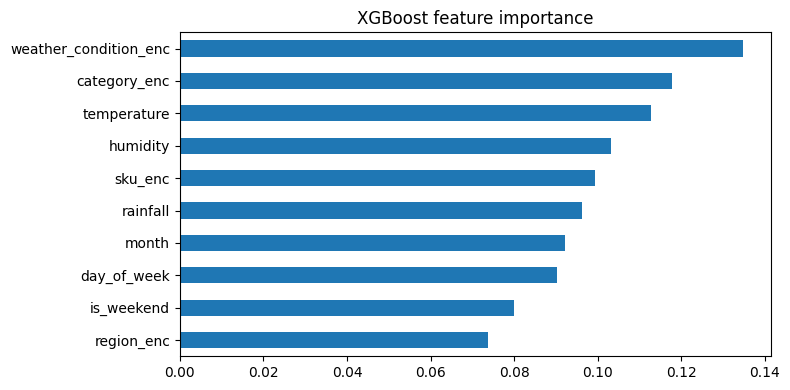

In [54]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importance.round(3))

plt.figure(figsize=(8, 4))
importance.plot(kind="barh")
plt.title("XGBoost feature importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=100)
plt.show()

In [56]:
artifact = {
    "model": model,
    "encoders": encoders,
    "feature_cols": feature_cols,
}

with open("forecast_model.pkl", "wb") as f:
    pickle.dump(artifact, f)


In [ ]:
# col = ['revenue', 'region', 'temperature',
#        'rainfall', 'humidity', 'weather_condition', 'name', 'category',
#        'home_region', 'month', 'day_of_week', 'is_weekend']

# X = df[col]
# Y = df["qty"]

In [29]:
X.shape

(9156, 10)

In [28]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=3)
model.fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
x_input = []

,revenue,region,temperature,rainfall,humidity,weather_condition,name,category,home_region,month,day_of_week,is_weekend
0,3953.37,North,16.7,40.9,67.0,Rainy,Epilator,Personal Care,South,10,0,0
1,18397.09,South,24.4,57.4,82.0,Rainy,Hair Trimmer,Personal Care,Central,6,0,0
2,88407.28,North,20.2,352.8,75.9,Thunderstorm,LED TV 32 inch Pro,Electronics,West,5,2,0
3,235192.77,West,20.6,64.6,66.5,Rainy,Home Theater System,Electronics,Central,4,1,0
4,3525.75,North,44.1,1.2,30.6,Sunny,Mosquito Racket,Home Care,West,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9151,143058.48,West,22.6,0.0,41.6,Partly Cloudy,UPS,Electronics,Central,3,1,0
9152,70198.39,Central,47.0,0.0,40.8,Heatwave,Home Theater System,Electronics,Central,3,5,1
9153,60195.66,East,16.9,0.0,69.9,Cloudy,Air Fryer Pro,Kitchen Appliances,South,1,0,0
9154,58338.85,East,13.5,27.7,77.8,Rainy,Humidifier,Home Appliances,Central,1,1,0
